# Ground-state energy of a stretched hydrogen chain

Four hydrogen atoms in a row, 2 Å apart, form a strongly correlated molecule, whose ground-state energy is the smallest eigenvalue of an 8-qubit Pauli-sum Hamiltonian. ADAPT-GCIM computes it in a small basis of many-electron states, optimizing no angle, and the notebook compares it with the exact energy.

Install with `python -m pip install "nwqlib[aer,notebook,chemistry]"`. To work on NWQLib itself, run `python -m pip install -e ".[aer,notebook,chemistry]"` in a clone of the repository instead. The notebook simulates circuits of at most 8 qubits and runs in about 19 s on an Apple M3 Max with 36 GiB of memory (Python 3.12.14, Qiskit 2.5.2, Aer 0.17.2).

> **How to read this notebook.** The next cells compute the energy and show it with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Section 6: another molecule, or your own Hamiltonian as a Pauli sum
> - Section 7 and Go deeper A to D: what NWQLib adds, the method in detail
> - Appendix A and B: the circuit counts and a saved result

In [1]:
from math import pi
from time import perf_counter

from nwqlib import solve
from nwqlib.algorithms.gcim import build_gcim_chemistry_problem

BOND_LENGTH = 2.0         # angstrom, stretched so that CCSD falls below the exact energy
GEOMETRY = "; ".join(f"H 0 0 {index * BOND_LENGTH}" for index in range(4))
BASIS = "sto-3g"          # one orbital per atom: 8 spin orbitals, 8 qubits
ACTIVE_SPACE = (4, 4)     # (electrons, spatial orbitals), all active, so CASCI is the exact (FCI) energy
POOL = "spin_adapted_sd"  # spin-adapted generalized singles and doubles (Zheng et al., arXiv:2312.07691v3, Appendix E)
THETA = pi / 4            # fixed angle of every generator, as in all ADAPT-GCIM runs of the paper (arXiv:2312.07691v3)
MAX_ITERATIONS = 8        # the eighth generator brings the error to roundoff (Section 3)

started = perf_counter()
# Hartree–Fock with PySCF, the qubit Hamiltonian and three classical reference energies.
molecule = build_gcim_chemistry_problem(GEOMETRY, basis=BASIS, active_space=ACTIVE_SPACE,
                                        reference_methods=("mp2", "ccsd", "casci"))
problem = molecule.eigenproblem()
method = molecule.adapt_method(pool=POOL, theta=THETA, max_iterations=MAX_ITERATIONS)
result = solve(problem, method=method, execution="classical", seed=7, progress=False)  # exact matrix elements
seconds = perf_counter() - started
E_FCI = molecule.reference_panel["e_casci"]  # exact energy in this basis, hartree

In [2]:
# Display helpers for tables, figures and the result card, the circuit counts of Appendix A and the Krylov
# dimension of Go deeper C. They read the records passed to them and run no plan or solve.
from html import escape

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
MILLIHARTREE = 1e3          # hartree to millihartree
CHEMICAL_ACCURACY = 1.6e-3  # hartree, about 1 kcal/mol


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "not available"
    if isinstance(value, (bool, np.bool_, str)):
        return str(value)
    if isinstance(value, (int, np.integer)) or isinstance(value, (float, np.floating)) and float(value).is_integer():
        return f"{int(value):,}"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (tuple, list)):
        return ", ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and in kilobytes or megabytes."""
    if count >= 1e6:
        return f"{count:,} bytes ({count / 1e6:.3g} MB)"
    return f"{count:,} bytes" + (f" ({count / 1e3:.3g} kB)" if count >= 1e3 else "")


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed quantities as a table, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    table = ("<table><thead><tr>" + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def amount(estimate, metric, location=None):
    """The value of one quantity of a resource estimate, or None when the estimate leaves it unknown."""
    quantity = estimate.quantity(metric) if location is None else estimate.quantity(metric, location=location)
    if quantity.fact.availability != "concrete":
        return None
    value = quantity.fact.value
    return value.numerator if value.kind == "rational" else value.value


def pair_circuits(basis_states):
    """Circuits of a run with exact probabilities, one per pair of basis states, gradients included (Appendix A)."""
    return basis_states * (basis_states + 1) // 2


def hadamard_tests(basis_states, terms):
    """Hadamard tests of all overlap and Hamiltonian matrix elements of a run with finite shots (Appendix A)."""
    return basis_states * terms + basis_states * (basis_states - 1) // 2 * (2 * terms + 2)


def excitation(result, index):
    """Readable name of one pool member in terms of spatial molecular orbitals."""
    member = result.plan.reconstruction.pool[index]
    orbitals = member.spatial_indices
    if member.family == "single":
        return f"single {orbitals[0]} ↔ {orbitals[1]}"
    return f"{member.family.replace('double_', '')} double {orbitals[0]},{orbitals[1]} ↔ {orbitals[2]},{orbitals[3]}"


def krylov_dimension(hamiltonian, occupations, *, rtol=1e-10, max_vectors=64):
    """Numerical Krylov dimension of H from a basis state, and whether the space was exhausted.

    Two-pass Gram–Schmidt on H − trace(H) I/n scaled by its infinity norm, stopped when the relative residual
    falls to ``rtol`` or after ``max_vectors`` vectors.
    """
    n = len(hamiltonian)
    a = np.array(hamiltonian, dtype=np.complex128)
    a[np.diag_indices(n)] -= np.trace(a).real / n
    scale = float(np.linalg.norm(a, ord=np.inf))
    if scale == 0:
        return 1, True
    a /= scale
    basis = np.zeros((n, min(n, max_vectors)), dtype=np.complex128)
    basis[sum(1 << mode for mode, occupied in enumerate(occupations) if occupied), 0] = 1.0
    for j in range(basis.shape[1]):
        w = a @ basis[:, j]
        for _ in range(2):
            for i in range(j + 1):
                w -= np.vdot(basis[:, i], w) * basis[:, i]
        residual = float(np.linalg.norm(w))
        if residual <= rtol or j + 1 == n:
            return j + 1, True
        if j + 1 == basis.shape[1]:
            return j + 1, False
        basis[:, j + 1] = w / residual


def show_card(result, exact, references, molecule, host_cost, circuit_cost, seconds):
    """Show the result card: the answer against the exact energy, the quantum and classical cost, the figure and steps."""
    errors = np.array([MILLIHARTREE * (step.energy - exact) for step in result.history])
    closest = min(references, key=lambda name: abs(references[name] - exact))
    gap = MILLIHARTREE * (references[closest] - exact)
    verdict = "within" if abs(errors[-1]) < MILLIHARTREE * CHEMICAL_ACCURACY else "outside"
    cx = amount(circuit_cost, "cx")
    display(HTML(
        f"<p><strong>Result.</strong> After {result.history[-1].iteration} iterations, without optimizing any angle, "
        f"the ADAPT-GCIM energy lies {abs(errors[-1]):.2g} mHa from the exact (FCI) energy, {verdict} chemical "
        f"accuracy (1.6 mHa). The closest classical approximation, {closest}, lies {abs(gap):.2g} mHa "
        f"{'below' if gap < 0 else 'above'} it. Execution: <code>execution=\"classical\"</code>, every matrix "
        f"element evaluated exactly from state vectors on this computer. Output: <code>result.eigenvalue</code>, "
        f"the energy in hartree.</p>"
        f"<p><strong>Cost.</strong> Quantum, if run as circuits: {molecule.num_qubits + 1} qubits per circuit, "
        f"{pair_circuits(len(result.pencil.overlap))} circuits with exact readout and no shots, "
        f"{'CX gates not predicted (no gate-count formula for these circuits)' if cx is None else f'{cx:,} CX gates'}. "
        f"Classical: peak memory {format_bytes(amount(host_cost, 'known_memory', 'host'))} of known buffers, stated "
        f"before the run, classical work {result.data.trace.host_work_reserved:,} units (a planning quantity, not "
        f"seconds), {seconds:.1f} s on this computer, chemistry setup included.</p>"))
    fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
    iterations = [step.iteration for step in result.history]
    ax.semilogy(iterations, np.maximum(np.abs(errors), 1e-9), "o-", color="#0072B2", label="ADAPT-GCIM")
    ax.axhspan(1e-9, MILLIHARTREE * CHEMICAL_ACCURACY, color="#009E73", alpha=0.12, label="Chemical accuracy")
    for (name, energy), color in zip(references.items(), ("#999999", "#E69F00", "#D55E00"), strict=True):
        ax.axhline(MILLIHARTREE * abs(energy - exact), linestyle="--", color=color, label=f"|{name} error|")
    ax.set(xlabel="ADAPT iteration", ylabel="|E − E_FCI| [mHa]", ylim=(1e-9, 1e3), xticks=iterations,
           title="Energy error, matrix elements evaluated exactly (floored at 1e-9 mHa)")
    ax.legend(fontsize=8, loc="lower left")
    plt.show()
    steps = (
        f"Ran Hartree–Fock with PySCF, fixed the sign of every molecular orbital, mapped the electronic Hamiltonian "
        f"to {len(molecule.hamiltonian)} Pauli strings on {molecule.num_qubits} qubits with the Jordan–Wigner "
        f"transformation and computed the MP2, CCSD and FCI reference energies.",
        f"Built the pool of {len(result.plan.reconstruction.pool)} spin-adapted excitation generators and, in each "
        f"iteration, selected the one with the largest energy gradient at the current state.",
        f"Evaluated the overlaps and Hamiltonian matrix elements between all {len(result.pencil.overlap)} basis "
        f"states, dropped nearly dependent directions below the overlap cutoff and solved the generalized "
        f"eigenvalue problem Hc = ESc.",
        "Kept every matrix element in the result, so another overlap cutoff needs no new evaluation (Go deeper C).",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))

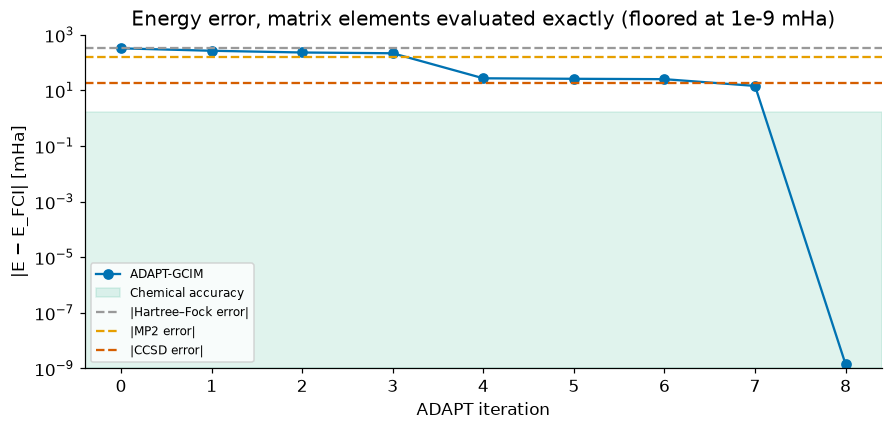

In [3]:
from nwqlib import estimate, plan

references = {name: molecule.reference_panel[key] for name, key in
              (("Hartree–Fock", "e_hf"), ("MP2", "e_mp2"), ("CCSD", "e_ccsd"))}  # classical methods, for comparison
host_cost = estimate(result.plan)  # the classical cost of this run, stated before it ran
circuit_plan = plan(problem, method=molecule.adapt_method(pool=POOL, theta=THETA, max_iterations=MAX_ITERATIONS),
                    execution="quantum", seed=7)  # planned as circuits, not run
circuit_cost = estimate(circuit_plan)
show_card(result, E_FCI, references, molecule, host_cost, circuit_cost, seconds)

**Your own problem.** Section 6 has a template cell for a Pauli sum you supply, and explains how to change the molecule.

## 1. Will it run?

**`plan` checks your problem against the limits before anything is evaluated, and a refusal names the setting and the amount.**

- **Input.** A Qiskit `SparsePauliOp`, or a dense or sparse matrix for exact evaluation. The chemistry helper builds the Pauli sum from a geometry with PySCF and OpenFermion.
- **Initial state.** The methods start from a state with a sizable overlap with the ground state, here the Hartree–Fock state.
- **Output.** `result.eigenvalue`, in the unit of the `Eigenproblem`, the smallest eigenvalue of a projected problem.
- **Size.** Exact evaluation holds state vectors of the full Hamiltonian in classical memory. As circuits, the Aer simulator accepts 20 qubits by default (Section 4).

The cell plans QCELS, another eigenvalue method of this family (Go deeper D), on the dense 256 × 256 matrix of the chain. With `max_work` set to 100,000,000 for this demonstration (the default is 1,000,000,000), planning refuses it before any evaluation. The remedy is the default `max_work`, and the solve takes under a second.

In [4]:
from nwqlib import Eigenproblem
from nwqlib.algorithms import QCELS

hamiltonian = molecule.hamiltonian.to_matrix()  # dense 256 × 256 matrix, hartree
initial_vector = np.zeros(len(hamiltonian))     # the Hartree–Fock basis state
initial_vector[sum(1 << mode for mode, occupied in enumerate(molecule.reference_occupations) if occupied)] = 1.0
dense_problem = Eigenproblem(A=hamiltonian, unit="Hartree")

DEMONSTRATION_MAX_WORK = 100_000_000  # below what this plan needs, to show the refusal
started = perf_counter()
try:
    plan(dense_problem, method=QCELS(initial_state=initial_vector, max_time=40.0, num_times=64,
                                     max_work=DEMONSTRATION_MAX_WORK), execution="classical", seed=7)
except ValueError as refusal:
    print(f"Refused after {perf_counter() - started:.4f} s, before any evaluation:\n{refusal}")

qcels_plan = plan(dense_problem, method=QCELS(initial_state=initial_vector, max_time=40.0, num_times=64),
                  execution="classical", seed=7)  # the remedy: the default max_work
qcels_cost = estimate(qcels_plan)
qcels_long = solve(qcels_plan, progress=False)
show_table([
    ("Peak memory of known buffers", format_bytes(amount(qcels_cost, "known_memory", "host")),
     "Stated by estimate before the run"),
    ("Work of the evaluation", amount(qcels_cost, "classical_work"),
     "Units, a planning quantity, not seconds. Estimate"),
    ("Error against FCI [mHa]", MILLIHARTREE * (qcels_long.eigenvalue - E_FCI), "Measured against reference"),
], headers=("At the default max_work", "Value", "Meaning"))

Refused after 0.0002 s, before any evaluation:
selected QPE numerical/schedule work exceeds QCELS.max_work: requires work=135266304, bytes=10518528; max_work=100000000, max_bytes=10000000000. Raise QCELS.max_work to at least 135266304.


At the default max_work,Value,Meaning
Peak memory of known buffers,"10,524,160 bytes (10.5 MB)",Stated by estimate before the run
Work of the evaluation,"135,452,160","Units, a planning quantity, not seconds. Estimate"
Error against FCI [mHa],-0.416,Measured against reference


Planning checks the work in stages, and the message names the amount of the stage it was checking. A later stage of this plan needs more than that amount and more than the estimate in the table, so a cap raised only to the named amount would bring a second refusal with the later stage's amount. The default leaves room for both stages.

## 2. What it costs

**As circuits, the quantum cost is circuits, qubits and shots. The classical cost is memory, work and time on this computer.** No gate-count formula covers these circuits, so CX gates, depth and T gates are not predicted.

The card cell planned the chain as circuits without running them.

`estimate` predicts the first iteration, because ADAPT chooses later circuits from earlier results. The pair rule of Appendix A counts the whole run, and Go deeper B checks it against executed circuits on H₂.

In [5]:
basis_states = len(result.pencil.overlap)
pauli_terms = sum(1 for label, _ in molecule.hamiltonian.to_list() if set(label) != {"I"})
show_table([
    ("System qubits", amount(circuit_cost, "system", "logical_device"), "Predicted by estimate"),
    ("Qubits per pair circuit", molecule.num_qubits + 1, "System qubits and one ancilla"),
    ("Circuits of the first iteration, exact readout", amount(circuit_cost, "settings"), "Predicted by estimate"),
    ("Circuits of the whole run, exact readout", pair_circuits(basis_states),
     f"Pair rule, {basis_states} basis states. The gradients reuse these circuits"),
    ("Shots, exact readout", amount(circuit_cost, "shots"), "Predicted by estimate"),
    ("Circuits with finite shots", hadamard_tests(basis_states, pauli_terms),
     f"Hadamard tests of the matrix elements, {pauli_terms} Pauli terms. The gradients add more"),
    *[(label, "not predicted", "No gate-count formula for these circuits")
      for label, metric in (("CX gates", "cx"), ("Depth", "logical_depth"), ("T gates", "t"))
      if amount(circuit_cost, metric) is None],
], headers=("Quantum cost, the chain as circuits", "Count", "Source"))

"Quantum cost, the chain as circuits",Count,Source
System qubits,8,Predicted by estimate
Qubits per pair circuit,9,System qubits and one ancilla
"Circuits of the first iteration, exact readout",3,Predicted by estimate
"Circuits of the whole run, exact readout",136,"Pair rule, 16 basis states. The gradients reuse these circuits"
"Shots, exact readout",0,Predicted by estimate
Circuits with finite shots,"47,344","Hadamard tests of the matrix elements, 184 Pauli terms. The gradients add more"
CX gates,not predicted,No gate-count formula for these circuits
Depth,not predicted,No gate-count formula for these circuits
T gates,not predicted,No gate-count formula for these circuits


In [6]:
trace = result.data.trace
show_table([
    ("Peak memory", format_bytes(amount(host_cost, "known_memory", "host")), "Not measured"),
    ("Work [units, a planning quantity, not seconds]",
     f"{amount(host_cost, 'construction_work'):,} for construction, upper bound. The evaluation is checked one "
     f"query at a time", f"{trace.host_work_reserved:,} counted for the evaluation"),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"{seconds:.1f} s for the chemistry setup and the solve, "
     f"{sum(event.timing.seconds for event in trace.events):.2f} s of it in its {len(trace.events)} classical evaluations"),
], headers=("Classical cost", "Before the run", "Recorded by the run"))

Classical cost,Before the run,Recorded by the run
Peak memory,"437,776 bytes (438 kB)",Not measured
"Work [units, a planning quantity, not seconds]","31,627 for construction, upper bound. The evaluation is checked one query at a time","535,339,520 counted for the evaluation"
Stored run data,Not predicted,"2,553,668 bytes (2.55 MB)"
Time on this computer,Not predicted,"13.7 s for the chemistry setup and the solve, 0.12 s of it in its 144 classical evaluations"


- **Peak memory** counts the known buffers of the evaluation: the cached state vectors, the action tables and the Hamiltonian. Python, PySCF and the rest of the process add to it.
- **Work.** Each evaluation is checked against `max_products` before it starts, because ADAPT chooses the next queries from earlier results. No total is therefore stated before the run.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**The energy is measured against the exact FCI energy, and each row says which kind of number it is.** With exact matrix elements the energy is a Rayleigh–Ritz value, which in exact arithmetic cannot fall below the exact energy.

In [7]:
pencil = result.pencil
show_table([
    ("Error against FCI [mHa]", MILLIHARTREE * (result.eigenvalue - E_FCI),
     "Measured against reference, the CASCI energy over all orbitals"),
    ("Lower bound on the energy", f"{E_FCI:.6f} Ha, the FCI energy",
     "Proven for exact matrix elements in exact arithmetic (Rayleigh–Ritz). Floating-point roundoff can move the "
     "computed energy slightly below it"),
    ("CCSD error [mHa]", MILLIHARTREE * (references["CCSD"] - E_FCI), "Measured against reference, for comparison"),
    ("Projected residual ‖Hc − ESc‖", pencil.projected_residual, "Measured: accuracy of the small eigensolve"),
    ("Overlap condition number", pencil.overlap_condition_number, "Measured: sensitivity to errors in S and H"),
    ("Ground state established by the run alone", None,
     "Unavailable. The result's report says: " + result.report()["summary"].splitlines()[1]),
], headers=("Quantity", "Value", "Kind of number"))

Quantity,Value,Kind of number
Error against FCI [mHa],-1.39e-09,"Measured against reference, the CASCI energy over all orbitals"
Lower bound on the energy,"-1.897781 Ha, the FCI energy",Proven for exact matrix elements in exact arithmetic (Rayleigh–Ritz). Floating-point roundoff can move the computed energy slightly below it
CCSD error [mHa],-18.3,"Measured against reference, for comparison"
Projected residual ‖Hc − ESc‖,5.77e-14,Measured: accuracy of the small eigensolve
Overlap condition number,6.25e+06,Measured: sensitivity to errors in S and H
Ground state established by the run alone,not available,Unavailable. The result's report says: processed-input projected estimate; ground identity and adaptive coverage not established


**The number of iterations trades accuracy for circuits.** Each iteration adds two basis states, so the error falls in steps while the circuits grow with the square of the basis. The table reads both from this run.

In [8]:
show_table([(step.iteration, "Hartree–Fock state" if step.iteration == 0 else excitation(result, step.selected[-1]),
             MILLIHARTREE * (step.energy - E_FCI), pair_circuits(2 * step.iteration))
            for step in result.history],
           headers=("Iteration", "Generator added", "Error [mHa]", "Circuits, exact readout, cumulative"))

Iteration,Generator added,Error [mHa],"Circuits, exact readout, cumulative"
0,Hartree–Fock state,322,0
1,"singlet double 0,1 ↔ 2,3",264,3
2,single 0 ↔ 2,228,10
3,single 1 ↔ 3,214,21
4,"triplet double 0,1 ↔ 0,3",27,36
5,"singlet double 1,1 ↔ 1,3",25.9,55
6,"singlet double 0,2 ↔ 1,1",25.1,78
7,"triplet double 0,1 ↔ 1,2",14.3,105
8,"singlet double 1,3 ↔ 2,2",-1.39e-09,136


With the default parameters the first three generators leave the error above 200 mHa, and a double excitation at iteration 4 brings it to about 27 mHa. The eighth generator brings it to the level of floating-point roundoff.

## 4. How large can I go?

**The local simulator, the circuit limit and the work caps set the size. Beyond them, `plan` and `estimate` still give the cost.** The table lists the limits this run had and the chain's use of them.

[Planning at scale](resource_estimation_at_scale.ipynb) plans a fixed GCiM trial basis at 80 to 100 qubits, sizes no simulator holds.

In [9]:
limits = trace.limits
show_table([
    ("Qubits the local simulator accepts", limits.max_simulation_qubits,
     f"Default. A pair circuit of this chain uses {molecule.num_qubits + 1}"),
    ("Circuits per run", limits.max_total_circuits,
     f"Default max_total_circuits. This run as circuits needs {pair_circuits(basis_states)}"),
    ("Basis states", method.max_basis_size, f"Default max_basis_size, two per iteration. This run uses {basis_states}"),
    ("Scalar products per evaluation", method.max_products,
     "Default max_products. It also covers planning the chain as circuits"),
    ("Exact evaluation: peak memory", format_bytes(amount(host_cost, "known_memory", "host")),
     "Known buffers, stated by estimate before the run"),
], headers=("Limit or cost", "Value", "Meaning"))

Limit or cost,Value,Meaning
Qubits the local simulator accepts,20,Default. A pair circuit of this chain uses 9
Circuits per run,512,Default max_total_circuits. This run as circuits needs 136
Basis states,64,"Default max_basis_size, two per iteration. This run uses 16"
Scalar products per evaluation,"1,000,000,000",Default max_products. It also covers planning the chain as circuits
Exact evaluation: peak memory,"437,776 bytes (438 kB)","Known buffers, stated by estimate before the run"


## 5. What does it assume?

**The runs are noiseless, and every count is a logical count.** Exact evaluation and the circuits of this notebook use exact outcome probabilities, and finite shots are sampled without noise.

The same finite-shot request runs with a noise model on the local simulator ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

The FCI reference is exact only within the STO-3G basis and the active space, so every energy here describes that model of the molecule.

## 6. Another molecule, or your own Hamiltonian

The cell below is the eigenvalue workflow without the chemistry helper. It writes H₂ at 0.74 Å in the STO-3G basis as 15 Pauli strings and compares Lanczos and ADAPT-GCIM with exact diagonalization. Replace `my_H` and `my_initial_state` with your own.

- **Another molecule.** Change `GEOMETRY`, `BASIS` and `ACTIVE_SPACE` in the first cell and run the notebook again. For example, `"Li 0 0 0; H 0 0 1.6"` with `ACTIVE_SPACE = (2, 5)` is a 10-qubit LiH problem.
- **Active space.** When it leaves orbitals out, CASCI is exact only within it, while MP2 and CCSD use all orbitals.
- **Hamiltonian.** A Qiskit `SparsePauliOp`, in which qubit 0 is the rightmost character of each label. The 15 coefficients are the Jordan–Wigner coefficients rounded to eight decimals, in the spin-orbital order of `build_gcim_chemistry_problem`. A dense or sparse matrix works for exact evaluation ([Supply inputs](../docs/inputs.md)).
- **Initial state.** `ingest_occupation("1100", num_qubits=4)` prepares the basis state with qubits 0 and 1 occupied, listing qubit 0 first. A product state, a vector or a Qiskit circuit also works.
- **Pool.** `pool="spin_adapted_sd"` with `n_spatial_orbitals=2` assumes the interleaved order of the chemistry helper, with the two spins of orbital p on qubits 2p and 2p + 1. For a Hamiltonian that is not molecular, start with Lanczos or QCELS, or pass your own generators ([GCiM guide](../docs/algorithms/gcim.md)).
- **Size limits.** Both solves run as circuits on the Aer simulator. Lanczos adds qubits that address the Pauli terms, and each ADAPT pair circuit adds one ancilla. The default limit of 512 circuits allows 15 ADAPT iterations with exact readout.
- **Output.** `my_lanczos.eigenvalue` and `my_adapt.eigenvalue`, in hartree here. With exact matrix elements each lies at or above the ground-state energy but does not certify it.

In [10]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp

from nwqlib import Eigenproblem, solve
from nwqlib.algorithms import ADAPT, Lanczos
from nwqlib.problems import ingest_occupation

my_H = SparsePauliOp.from_list([  # your Hamiltonian, here H2 at 0.74 Å in hartree
    ("IIII", -0.09706627), ("IIIZ", 0.17141283), ("IIZI", 0.17141283), ("IZII", -0.22343154),
    ("ZIII", -0.22343154), ("IIZZ", 0.16868898), ("IZIZ", 0.12062523), ("ZIIZ", 0.16592785),
    ("IZZI", 0.16592785), ("ZIZI", 0.12062523), ("ZZII", 0.17441288), ("XXYY", -0.04530262),
    ("YYXX", -0.04530262), ("XYYX", 0.04530262), ("YXXY", 0.04530262),
])
my_initial_state = ingest_occupation("1100", num_qubits=4)  # your initial state, here the Hartree–Fock state

my_problem = Eigenproblem(A=my_H, unit="Hartree")
my_lanczos = solve(my_problem, method=Lanczos(initial_state=my_initial_state, krylov_dimension=2), seed=7,
                   progress=False)
my_adapt = solve(my_problem, method=ADAPT(initial_state=my_initial_state, pool="spin_adapted_sd", n_spatial_orbitals=2),
                 seed=7, progress=False)
my_exact = np.linalg.eigvalsh(my_H.to_matrix())[0]
print(f"exact diagonalization {my_exact:.6f} Ha, error of Lanczos {my_lanczos.eigenvalue - my_exact:.1e} Ha, "
      f"of ADAPT-GCIM {my_adapt.eigenvalue - my_exact:.1e} Ha")

exact diagonalization -1.137284 Ha, error of Lanczos -1.6e-15 Ha, of ADAPT-GCIM 0.0e+00 Ha


## 7. What NWQLib adds

- **Planning beyond simulation.** `plan` and `estimate` work at sizes no simulator holds ([Planning at scale](resource_estimation_at_scale.ipynb)).
- **The formula behind every number.** The circuit counts follow the pair rule of Appendix A, which Go deeper B checks against executed circuits. [Mathematics](../docs/mathematics.md) gives the resource formulas, and the resource notebook compares them with compiled circuits at small sizes.
- **One argument switches the method.** `method=Lanczos(...)` or `method=QCELS(...)` in the same `solve` call replaces ADAPT-GCIM (Go deeper D).
- **Reanalysis without new evaluation.** The result stores every matrix element, so `result.analyze` solves again with another overlap cutoff (Go deeper C).
- **Saved and reloaded.** A saved result reloads with its matrix elements, and its numbers can be recomputed (Appendix B).

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## Go deeper

### A. The chain, its reference energies and ADAPT-GCIM step by step

**Why is this chain hard for classical methods, and what does each ADAPT-GCIM iteration do?** This section reads the references and the run, and runs no solve.

The minimal STO-3G basis gives each hydrogen atom one orbital. Four spatial orbitals hold four electrons, and each spin orbital becomes one qubit. `ACTIVE_SPACE = (4, 4)` keeps every orbital active, so complete-active-space CI (CASCI) is exact diagonalization, the full configuration interaction (FCI) reference.

Errors are in millihartree (mHa). A negative error means an energy below the exact value, which a variational method can never produce. CCSD, the usual workhorse of quantum chemistry, is not variational, and at this bond length its error has the wrong sign.

In [11]:
show_table([
    ("Qubits", molecule.num_qubits, f"{molecule.n_spatial_orbitals} spatial orbitals, {molecule.num_electrons} electrons"),
    ("Pauli terms", len(molecule.hamiltonian), "Including the constant nuclear-repulsion term"),
    ("FCI energy", f"{E_FCI:.2f}", "Hartree, exact in this basis"),
    *[(name + " error", MILLIHARTREE * (energy - E_FCI), "mHa relative to FCI") for name, energy in references.items()],
])

Quantity,Value,Meaning
Qubits,8,"4 spatial orbitals, 4 electrons"
Pauli terms,185,Including the constant nuclear-repulsion term
FCI energy,-1.90,"Hartree, exact in this basis"
Hartree–Fock error,322,mHa relative to FCI
MP2 error,154,mHa relative to FCI
CCSD error,-18.3,mHa relative to FCI


Every member $A_k$ of the operator pool is an anti-Hermitian excitation operator, a single excitation between two spatial orbitals or a spin-adapted double excitation. It defines a unitary *generating function* $G_k(\theta)=e^{\theta A_k}$, whose angle stays at $\pi/4$. Starting from the Hartree–Fock state $|\phi_0\rangle$, each iteration does three things:

1. **Select.** Evaluate the energy gradient $\langle\psi|[H,A_k]|\psi\rangle$ for every pool member at the current product state $|\psi\rangle=G_{k_m}(\theta)\cdots G_{k_1}(\theta)|\phi_0\rangle$, and pick the largest in magnitude.
2. **Expand.** Add new basis states built from the selected generator, including its product with the earlier ones.
3. **Diagonalize.** Evaluate $H_{ij}=\langle\psi_i|H|\psi_j\rangle$ and $S_{ij}=\langle\psi_i|\psi_j\rangle$ for the new basis states and solve the generalized eigenvalue problem $Hc=ESc$.

The lowest generalized eigenvalue is the ADAPT-GCIM energy. It comes from a subspace, so in exact arithmetic it cannot fall below the exact energy when $H_{ij}$ and $S_{ij}$ are exact (the Rayleigh–Ritz principle).

With `execution="classical"` the gradients and matrix elements are exact, and the selection rule and eigenvalue problem are those of the quantum algorithm.

<details><summary>Sources, orbital signs and the stopping rule</summary>

ADAPT-GCIM comes from Zheng, Peng, Li, Yang and Kowalski, [*npj Quantum Information* **10**, 127 (2024)](https://doi.org/10.1038/s41534-024-00916-8), arXiv:2312.07691v3. Its Figure 4 follows the same algorithm on linear and square H₄, LiH, BeH₂ and H₆. This notebook uses a linear H₄ chain at a longer bond length than the paper's H₄ panels.

The selection rule is steps 5–7 of ADAPT-VQE (Grimsley et al., arXiv:1812.11173v2, Sec. II.B). The fixed angle and the basis growth follow the METHODS section of arXiv:2312.07691v3 (p. 9). $Hc=ESc$ is the discretized Hill–Wheeler equation, Eq. (13) of Zheng et al., arXiv:2212.09205v1.

The GCiM guide (`docs/algorithms/gcim.md`) links each step to its code.

The iterations depend on the signs of the molecular orbitals. Every generating function uses the same fixed angle, and replacing $A_k$ by $-A_k$ changes the states $e^{\theta A_k}\cdots|\phi_0\rangle$ that the basis spans.

NWQLib fixes each arbitrary orbital sign when it builds the Hamiltonian, so the same geometry gives the same iterations on every computer.

`MAX_ITERATIONS` caps the run. The ADAPT-GCIM paper stops a run once the energy has changed by less than $10^{-6}$ Ha in ten consecutive iterations, its setting for H₄, or in fewer iterations when 20% of the unselected pool members, rounded up, is smaller. NWQLib applies this rule within the cap.

With `MAX_ITERATIONS = 32`, the largest value the default cap of 64 basis states allows, the rule stops this run at iteration 18, ten iterations after the energy reached FCI.

</details>

### B. The same algorithm as quantum circuits

**Do quantum circuits give the same energies as the exact evaluation, and how many circuits does ADAPT-GCIM need?** The cell builds H₂ at 0.74 Å with the chemistry helper and runs ADAPT-GCIM once as circuits and once with exact evaluation, under a second.

With exact outcome probabilities each pair of basis states $\psi_i,\psi_j$ is prepared once, as the joint state $(|0\rangle|\psi_i\rangle+|1\rangle|\psi_j\rangle)/\sqrt2$ of one ancilla qubit and the system. The simulator reduces the final state to the overlap $\langle\psi_i|\psi_j\rangle$ and to $\langle\psi_i|H_0|\psi_j\rangle$, where $H_0$ is $H$ without its identity term.

A diagonal element needs only the system state $\psi_i$. The circuit of the current full product state also returns the commutator gradients of the selection step, so a screening adds no circuit.

<details><summary>Hadamard tests for finite shots</summary>

With finite shots each matrix element is measured with Hadamard tests, one circuit with a single ancilla qubit for every Pauli term of $H$ and for the real and imaginary parts.

Their ancilla outcome probabilities are $\tfrac12\pm\tfrac12\,\mathrm{Re}\langle\psi_i|P_k|\psi_j\rangle$ (arXiv:2312.07691v3, Appendix G, Eqs. (G4)–(G5)), and a phase gate $S^\dagger$ on the ancilla gives the imaginary part.

</details>

In [12]:
h2 = build_gcim_chemistry_problem("H 0 0 0; H 0 0 0.74", basis="sto-3g")
h2_method = h2.adapt_method(pool=POOL, theta=THETA)
h2_circuits = solve(h2.eigenproblem(), method=h2_method, execution="quantum", seed=7, progress=False)
h2_exact = solve(h2.eigenproblem(), method=h2_method, execution="classical", seed=7, progress=False)
h2_terms = sum(1 for label, _ in h2.hamiltonian.to_list() if set(label) != {"I"})
h2_executed = len({chunk.attempt for chunk in h2_circuits.data.observations.chunks})
instructions = [receipt.native_operations for receipt in h2_circuits.data.receipts]
show_table([
    ("Energy from circuits", h2_circuits.eigenvalue, "Hartree"),
    ("Energy from exact evaluation", h2_exact.eigenvalue, "Hartree, the evaluation used for the chain"),
    ("Difference", abs(h2_circuits.eigenvalue - h2_exact.eigenvalue), "Hartree"),
    ("Generator added in iteration 1", excitation(h2_circuits, h2_circuits.selected[0]),
     f"The same in both runs: {h2_circuits.selected == h2_exact.selected}"),
    ("Iterations", h2_circuits.history[-1].iteration, f"Stop reason: {h2_circuits.stop_reason}"),
    ("Circuits executed", h2_executed,
     f"Pair rule for {len(h2_circuits.pencil.overlap)} basis states: {pair_circuits(len(h2_circuits.pencil.overlap))}, "
     f"for any number of Pauli terms ({h2_terms} here)"),
    ("Qubits per circuit (at most)", h2.num_qubits + 1, f"{h2.num_qubits} system qubits and one ancilla"),
    ("Instructions per prepared circuit (min / median / max)",
     (min(instructions), int(np.median(instructions)), max(instructions)),
     "Recorded when each circuit was prepared, before compilation for a device"),
])

Quantity,Value,Meaning
Energy from circuits,-1.14,Hartree
Energy from exact evaluation,-1.14,"Hartree, the evaluation used for the chain"
Difference,2.22e-16,Hartree
Generator added in iteration 1,"singlet double 0,0 ↔ 1,1",The same in both runs: True
Iterations,1,Stop reason: gradient_norm_floor
Circuits executed,3,"Pair rule for 2 basis states: 3, for any number of Pauli terms (14 here)"
Qubits per circuit (at most),5,4 system qubits and one ancilla
Instructions per prepared circuit (min / median / max),"2, 154, 159","Recorded when each circuit was prepared, before compilation for a device"


The two runs agree to rounding and select the same generator. For H₂ one iteration is exact, because the ground state lies in the span of the Hartree–Fock state and the doubly excited state that the first generator adds. This run checks the circuits, not the convergence.

The chain as circuits fits the default `max_products`, and its 136 circuits fit the default `ExecutionLimits(max_total_circuits=512)`. With `shots=1000` the matrix elements are measured with Hadamard tests (Appendix A), and the gradients need one circuit per group of commuting Pauli terms.

Under the default limits, `solve` then refuses the first matrix evaluation before any of its circuits runs, and the message names the limit to raise. `limits=ExecutionLimits(max_total_circuits=..., max_total_shots=...)`, with `ExecutionLimits` from `nwqlib.execution`, must cover the larger totals.

### C. When the energy becomes exact, and another overlap cutoff

**Which directions does the final eigenvalue problem keep, and what changes with the overlap cutoff?** This section reads the stored result and solves four small eigenvalue problems, under a second.

The basis states overlap strongly, so some eigenvalues of the overlap matrix $S$ are tiny. NWQLib drops the directions whose overlap eigenvalue falls below the cutoff, $10^{-12}$ by default, before it solves $Hc=ESc$.

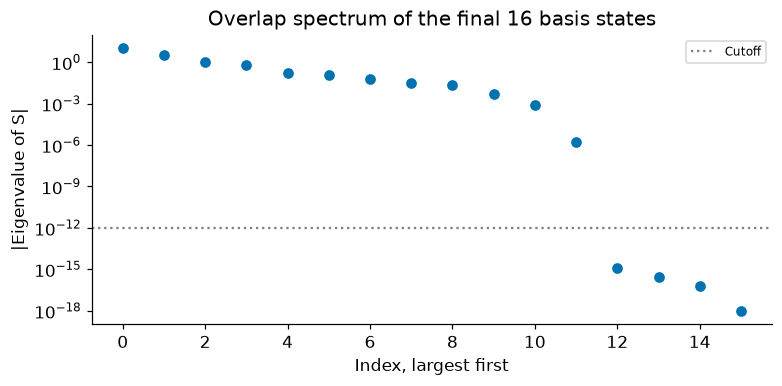

Quantity,Value,Meaning
Basis states / kept rank,"16, 12",Directions kept after the overlap cutoff
Numerical Krylov dimension by two-pass reorthogonalization,12 (exhaustion flag True),"Relative tolerance 1e-10 on the residual, relative to ||H - trace(H) I/n||_inf, with a flag for whether the 64-vector budget was exhausted. Compared with the kept ADAPT rank as a separate diagnostic."
Stop reason,max_iterations,max_iterations: the iteration budget was used


In [13]:
reachable, exhausted = krylov_dimension(hamiltonian, molecule.reference_occupations)
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.semilogy(np.abs(pencil.overlap_eigenvalues[::-1]), "o", color="#0072B2")
ax.axhline(pencil.overlap_cutoff, color="0.5", linestyle=":", label="Cutoff")
ax.set(xlabel="Index, largest first", ylabel="|Eigenvalue of S|",
       title=f"Overlap spectrum of the final {len(pencil.overlap)} basis states")
ax.legend(fontsize=8)
plt.show()
show_table([
    ("Basis states / kept rank", (len(pencil.overlap), pencil.kept_rank), "Directions kept after the overlap cutoff"),
    ("Numerical Krylov dimension by two-pass reorthogonalization",
     f"{reachable} (exhaustion flag True)" if exhausted else f"constructed {reachable} directions, vector limit reached",
     "Relative tolerance 1e-10 on the residual, relative to ||H - trace(H) I/n||_inf, with a flag for whether the "
     "64-vector budget was exhausted. Compared with the kept ADAPT rank as a separate diagnostic."),
    ("Stop reason", result.stop_reason, "max_iterations: the iteration budget was used"),
])

The Krylov count is the numerical dimension at the displayed tolerance. An equal number of kept ADAPT-GCIM directions does not establish that the two spaces coincide or contain the ground state.

Exact Rayleigh–Ritz recovers the ground energy when its trial space contains a ground-state eigenvector. Here the independently computed FCI energy establishes the accuracy. For another molecule, inspect the energy error and the overlap spectrum separately from the two dimension counts.

A small energy error does not by itself certify the ground state. For larger molecules, where FCI is out of reach, the convergence of the energy with iterations and the overlap diagnostics are the available evidence.

`result.analyze(overlap_cutoff=...)` solves the final eigenvalue problem again from the stored matrix elements, with no new evaluation, as one would for noisy matrix elements from finite shots. The table repeats the solve with larger cutoffs.

In [14]:
rows = []
for cutoff in (1e-12, 1e-4, 1e-3, 1e-2):
    reanalyzed = result.analyze(overlap_cutoff=cutoff)
    rows.append((f"{cutoff:.0e}", reanalyzed.pencil.kept_rank, reanalyzed.pencil.overlap_condition_number,
                 MILLIHARTREE * (reanalyzed.eigenvalue - E_FCI)))
show_table(rows, headers=("Overlap cutoff", "Kept directions", "Overlap condition number", "Error [mHa]"))

Overlap cutoff,Kept directions,Overlap condition number,Error [mHa]
1e-12,12,6.25e+06,-1.39e-09
1e-04,11,1.44e+04,14.3
1e-03,10,2.2e+03,73.6
1e-02,9,493,83.6


Discarding more nearly dependent directions lowers the condition number of $S$ by four orders of magnitude, which protects the solve against errors in the matrix elements. It also removes part of the ground state, and the energy error grows to tens of mHa.

The cutoff is therefore an analysis setting to choose from the accuracy of the matrix elements, and the stored result lets you try several without repeating the evaluation.

### D. Other eigenvalue methods on the chain

**How do Chebyshev Lanczos and QCELS, started from the same Hartree–Fock state, compare with ADAPT-GCIM on H₄?** The cell makes ten solves with exact evaluation, about 1 s, and plans each method's quantum circuit without running it.

**Chebyshev Lanczos** (Kirby, Motta and Mezzacapo, [*Quantum* **7**, 1018 (2023)](https://doi.org/10.22331/q-2023-05-23-1018), arXiv:2208.00567v4) builds a Krylov space from Chebyshev polynomials of $H$ applied to the initial state. Each extra Krylov dimension adds higher polynomial moments, measured through a block encoding of $H$.

**QCELS** (Ding and Lin, [*PRX Quantum* **4**, 020331 (2023)](https://doi.org/10.1103/PRXQuantum.4.020331), arXiv:2211.11973v2) measures the signal $\langle\phi_0|e^{-iHt}|\phi_0\rangle$ at times up to `max_time` and fits one complex exponential to it, whose frequency is the energy estimate.

Two quantities decide how well QCELS works. The squared overlap $p_0$ of the initial state with the ground state sets how strongly the ground-state frequency dominates the signal. `max_time` sets the longest coherent evolution, and with it the circuit depth.

<details><summary>What Ding and Lin's theorems cover, and how NWQLib chooses the times</summary>

At this bond length the Hartree–Fock state has $p_0=0.48$, below the 0.71 that the paper's accuracy guarantee for a single fit assumes, so the QCELS errors below are empirical results for this Hamiltonian.

QCELS measures $\langle\phi_0|U^p|\phi_0\rangle$ for integer powers $p$ of $U = e^{-i\tau H}$, that is at times $t = p\tau$, and fits a single complex exponential to these values by least squares (arXiv:2211.11973v2, Eqs. (9)–(13), p. 9). NWQLib makes this fit once, on one schedule of powers.

The paper's multi-level Algorithm 1 (p. 13) repeats the fit while doubling the time step, and its Theorem 2 (p. 14), which gives the Heisenberg-limited total cost, concerns that algorithm.

Theorem 1 (p. 14) covers a single fit on the consecutive times $t_n = n\tau$, $n = 0, \dots, N-1$, of their Eq. (6).

If $p_0$ exceeds 0.71 and $N\tau$ is of order $\sqrt{1-p_0}/\epsilon$, the fitted energy then lies within $\epsilon$ of the ground-state energy, modulo $2\pi/\tau$, with high probability once enough samples are taken.

For smaller overlaps their Sec. IV (p. 15) first finds a rough interval for the ground-state energy and applies a Fourier filter to the signal, after which a relative overlap above 0.71 takes the place of $p_0$. NWQLib does not implement that step.

NWQLib chooses the time step $\tau=0.9\pi/R$, where $R\ge|E|$ for every eigenvalue $E$. For a dense input $R$ is the largest absolute row sum of $H$. Every phase $\tau E$ then lies inside $(-\pi,\pi)$, so the fitted phase gives the energy without wrapping around.

The largest power $P$ is `max_time` divided by $\tau$, rounded down. The schedule holds every power from 0 to $P$ when $P$ is at most `num_times`, and otherwise keeps power 0 and spreads `num_times` integer powers over 1 to $P$.

The cell sets `num_times=64`, more than the largest $P$ it reaches, so every longest time gives the consecutive powers of their Eq. (6) in arXiv:2211.11973v2, the data set of Theorem 1.

Spread powers with nearly equal gaps $g$ would make the fit nearly periodic in energy with the shorter period $2\pi/(g\tau)$, and for some longest times a replica of the ground-state peak can then win the fit.

Exact evaluation removes the sampling error that Theorem 1 controls, but its overlap condition fails.

</details>

Both methods use exact evaluation here. QCELS evaluates the time signal from the dense matrix of Section 1, and as quantum circuits either method accepts the Pauli sum directly.

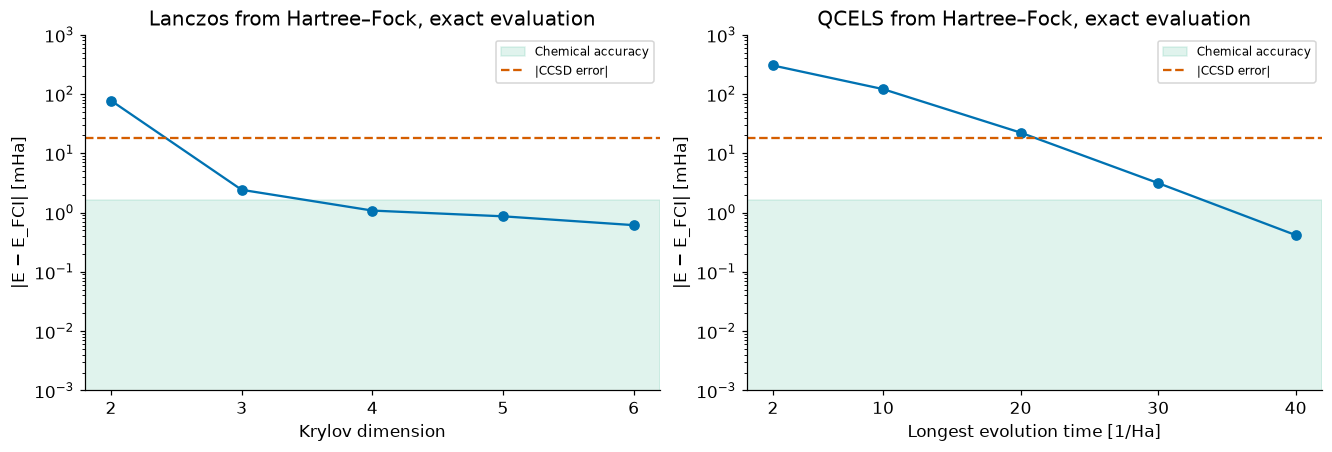

Method,Setting,"Error [mHa], exact evaluation",Qubits of the planned circuit,What the circuits contain
ADAPT-GCIM,8 iterations,-1.39e-09,9,Pair circuits of fixed-angle excitations. The circuit count grows with the basis size.
Lanczos,Krylov dimension 4,1.08,16,Repeated applications of a block encoding of H. Extra qubits address the Pauli terms.
QCELS,longest time 40/Ha,-0.416,9,"Controlled time evolution up to t = 40/Ha, that is 43 steps of τ."


In [15]:
from nwqlib.algorithms import QCELS, Lanczos
from nwqlib.problems import ingest_occupation

initial_state = ingest_occupation(molecule.reference_occupations, num_qubits=molecule.num_qubits)  # Hartree–Fock
overlap = abs(np.vdot(np.linalg.eigh(hamiltonian)[1][:, 0], initial_vector)) ** 2

krylov_dimensions = (2, 3, 4, 5, 6)  # brackets dimension 4, where Lanczos reaches chemical accuracy
lanczos_errors = [MILLIHARTREE * (solve(problem, method=Lanczos(initial_state=initial_state, krylov_dimension=k),
                                        execution="classical", seed=7, progress=False).eigenvalue - E_FCI)
                  for k in krylov_dimensions]

longest_times = (2.0, 10.0, 20.0, 30.0, 40.0)  # 1/hartree, from a fit that mixes eigenvalues (2) to one within chemical accuracy (40)
qcels_runs = [solve(dense_problem, method=QCELS(initial_state=initial_vector, max_time=t, num_times=64),
                    execution="classical", seed=7, progress=False) for t in longest_times]
qcels_errors = [MILLIHARTREE * (run.eigenvalue - E_FCI) for run in qcels_runs]
qcels_selection = qcels_runs[-1].plan.reconstruction

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, values, errors, xlabel, title in (
    (axes[0], krylov_dimensions, lanczos_errors, "Krylov dimension", "Lanczos from Hartree–Fock"),
    (axes[1], longest_times, qcels_errors, "Longest evolution time [1/Ha]", "QCELS from Hartree–Fock"),
):
    ax.semilogy(values, np.abs(errors), "o-", color="#0072B2")
    ax.axhspan(1e-6, MILLIHARTREE * CHEMICAL_ACCURACY, color="#009E73", alpha=0.12, label="Chemical accuracy")
    ax.axhline(MILLIHARTREE * abs(references["CCSD"] - E_FCI), linestyle="--", color="#D55E00", label="|CCSD error|")
    ax.set(xlabel=xlabel, xticks=values, ylabel="|E − E_FCI| [mHa]", title=title + ", exact evaluation",
           ylim=(1e-3, 1e3))
    ax.legend(fontsize=8)
plt.show()

lanczos_plan = plan(problem, method=Lanczos(initial_state=initial_state, krylov_dimension=krylov_dimensions[2]),
                    execution="quantum", seed=7)
qcels_plan = plan(problem, method=QCELS(initial_state=initial_state), execution="quantum", seed=7)
show_table([
    ("ADAPT-GCIM", f"{result.history[-1].iteration} iterations", MILLIHARTREE * (result.eigenvalue - E_FCI),
     molecule.num_qubits + 1, "Pair circuits of fixed-angle excitations. The circuit count grows with the basis size."),
    ("Lanczos", f"Krylov dimension {krylov_dimensions[2]}", lanczos_errors[2],
     amount(estimate(lanczos_plan), "logical_width", "logical_device"),
     "Repeated applications of a block encoding of H. Extra qubits address the Pauli terms."),
    ("QCELS", f"longest time {longest_times[-1]:g}/Ha", qcels_errors[-1],
     amount(estimate(qcels_plan), "logical_width", "logical_device"),
     f"Controlled time evolution up to t = {longest_times[-1]:g}/Ha, that is {qcels_selection.powers[-1].power} steps of τ."),
], headers=("Method", "Setting", "Error [mHa], exact evaluation", "Qubits of the planned circuit",
            "What the circuits contain"))
display(HTML(f"<p>Squared overlap p<sub>0</sub> of the Hartree–Fock state with the exact ground state: {overlap:.2f}. "
             f"QCELS time step τ = {qcels_selection.tau:.3g}/Ha, from the row-sum bound R = "
             f"{qcels_selection.spectral_radius_bound:.3g} Ha.</p>"))

With the default parameters, Lanczos reaches chemical accuracy with a four-dimensional Krylov space. Its circuits need more qubits, because the block encoding addresses each Pauli term with extra qubits.

QCELS keeps the 9-qubit width of ADAPT-GCIM but needs long coherent evolution. At the shortest time the fit locks onto a mixture of eigenvalues and the error is hundreds of mHa.

In this example, extending the longest time to 40/Ha separates the ground-state frequency, although the overlap stays below the 0.71 that the paper's guarantee assumes.

At longest times between the plotted ones the error can rise again, for example to 12 mHa at 35/Ha against 3 mHa at 30/Ha. The excited states that the Hartree–Fock state contains shift the fitted frequency by an amount that varies with the longest time.

`QCELS(max_time=...)` sets the circuit depth, and in this example a longer time lowers the error on the whole but not at every step. The Krylov dimension of Lanczos sets the number of measured moments.

## Appendix

### A. Circuit count of a quantum run of the chain

With exact probabilities each pair $i\le j$ of the $b$ basis states is one circuit, whose final state the simulator reduces to $S_{ij}$ and to the matrix element of $H$ without its identity term.

A diagonal pair prepares one basis state, and the circuit of each full product state also returns the gradients of that iteration's screening. Together,

$$N_{\rm exact}(b)=\frac{b(b+1)}{2},$$

for any number of Pauli terms. With finite shots and $P$ non-identity Pauli terms, each diagonal element $H_{ii}$ needs $P$ Hadamard tests for its real part, and $S_{ii}=1$ needs none. Each off-diagonal pair $i<j$ needs the real and imaginary parts of $S_{ij}$ and of every Pauli term of $H_{ij}$, so

$$N_{\rm Hadamard}(b)=bP+\frac{b(b-1)}{2}\,(2P+2),$$

and the gradients add one circuit per group of commuting Pauli terms at each screening. Circuits from earlier iterations are reused, so both are cumulative counts. The helper cell after the first code cell implements both, and the table evaluates them for the basis sizes of this run.

In [16]:
show_table([(step.iteration, 2 * step.iteration, pair_circuits(2 * step.iteration),
             hadamard_tests(2 * step.iteration, pauli_terms))
            for step in result.history[1:]],
           headers=("Iteration", "Basis states", "Exact circuits", "Hadamard tests (shots)"))
print(f"H2 check: the pair rule gives {pair_circuits(len(h2_circuits.pencil.overlap))} circuits, "
      f"and Go deeper B executed {h2_executed}.")

Iteration,Basis states,Exact circuits,Hadamard tests (shots)
1,2,3,738
2,4,10,"2,956"
3,6,21,"6,654"
4,8,36,"11,832"
5,10,55,"18,490"
6,12,78,"26,628"
7,14,105,"36,246"
8,16,136,"47,344"


H2 check: the pair rule gives 3 circuits, and Go deeper B executed 3.


### B. A saved result, reloaded and recomputed

`result.save` writes the plan, the result and every evaluated matrix element to a directory. Loading restores them without repeating any evaluation. The cell recomputes the card's energy error and a reanalysis from the loaded result and compares them with the original.

In [17]:
from pathlib import Path
from tempfile import mkdtemp

from nwqlib import load_result

restored = load_result(result.save(Path(mkdtemp()) / "h4-adapt-gcim"))
card_error = MILLIHARTREE * (result.eigenvalue - E_FCI)
restored_error = MILLIHARTREE * (restored.eigenvalue - E_FCI)
restored_cutoff = restored.analyze(overlap_cutoff=1e-4).eigenvalue
show_table([
    ("Error against FCI [mHa], recomputed from the loaded result", restored_error,
     "Equal to the card's value" if restored_error == card_error else "Differs from the card's value"),
    ("Energy at overlap cutoff 1e-4 [Ha], reanalyzed after loading", restored_cutoff,
     "Equal to the reanalysis of the original"
     if restored_cutoff == result.analyze(overlap_cutoff=1e-4).eigenvalue else "Differs"),
])
show_table([
    ("Plan identifier", result.plan_id, "The Hamiltonian, the configured method and the requested output"),
    ("Result identifier", result.content_id, "This eigenvalue and the observations it used"),
], details="Identifiers of the saved records")

Quantity,Value,Meaning
"Error against FCI [mHa], recomputed from the loaded result",-1.39e-09,Equal to the card's value
"Energy at overlap cutoff 1e-4 [Ha], reanalyzed after loading",-1.88,Equal to the reanalysis of the original


Quantity,Value,Meaning
Plan identifier,sha256:a45f040d4715cd97a5738df0c3150985f863916df01b91b60b4100c9817a1c08,"The Hamiltonian, the configured method and the requested output"
Result identifier,sha256:612e34c3a52c14ea6012313920f1f6b866b522271ed62f1f2ba45bfd03956976,This eigenvalue and the observations it used
